# Titanic Dataset — Data Cleaning, EDA & Preprocessing

**Elevate Labs — AI/ML Virtual Internship | Task 1**

**Objective:** Learn how to clean, explore, and prepare raw data for Machine Learning.

**Pipeline covered in this notebook:**
1. Import & explore the dataset (shape, dtypes, nulls)
2. Exploratory Data Analysis (EDA) — understand patterns before touching the data
3. Handle missing values (median / mode imputation)
4. Encode categorical features into numerical form
5. Detect & remove outliers (IQR method, visualized with boxplots)
6. Normalize / standardize numerical features
7. Final sanity checks & export the cleaned dataset

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## 1. Imports & Setup

In [38]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
sns.set_theme(style="whitegrid", context="notebook")

PALETTE = ["#2E5EAA", "#E8743B", "#4FB0A5", "#C6444B", "#8B6DB8", "#F2C14E"]
sns.set_palette(sns.color_palette(PALETTE))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.facecolor"] = "white"

print("Libraries loaded. Seaborn theme + custom palette set.")

Libraries loaded. Seaborn theme + custom palette set.


## 2. Load the Dataset & Basic Exploration

In [39]:
# Load the raw Titanic CSV
df = pd.read_csv("Titanic-Dataset.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [40]:
# Structural overview: column names, dtypes, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [41]:
#shape of the dataset numner of rows and columns
df.shape

(891, 12)

In [42]:
# Statistical summary of numeric columns (count, mean, std, min, quartiles, max)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [43]:
# Check for missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary.sort_values(by="missing_pct", ascending=False)

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


<Axes: >

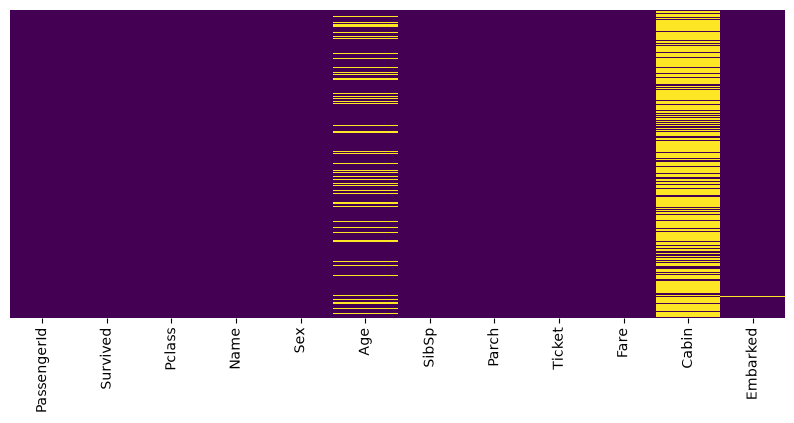

In [44]:
# Visualize missingness as a heatmap -- yellow streaks show WHERE data is missing.
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)

## 3. Handle Missing Values

Decisions, with reasoning:

| Column | Missing % | Action | Why |
|---|---|---|---|
| `Cabin` | ~77% | **Drop column** | Too sparse to impute reliably; imputing would mostly be guessing |
| `Name`, `Ticket`, `PassengerId` | 0% | **Drop column** | Unique identifiers with no predictive value for ML |
| `Age` | ~20% | **Median imputation** | Age is right-skewed with outliers (elderly passengers) — median is robust to that, unlike mean |
| `Embarked` | ~0.2% | **Mode imputation** | Categorical column, only 2 missing rows — safe to fill with the most frequent port |

In [45]:
# Drop columns that are either too sparse to impute (Cabin) or are pure
df_clean = df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])

# Age: numeric + skewed -> median is more robust to outliers than mean
age_median = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].fillna(age_median)

# Embarked: categorical, only 2 missing -> fill with the mode (most common port)
embarked_mode = df_clean["Embarked"].mode()[0]
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)


In [46]:
print(f"Filled Age missing values with median = {age_median}")
print(f"Filled Embarked missing values with mode = '{embarked_mode}'")
df_clean.isnull().sum()

Filled Age missing values with median = 28.0
Filled Embarked missing values with mode = 'S'


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

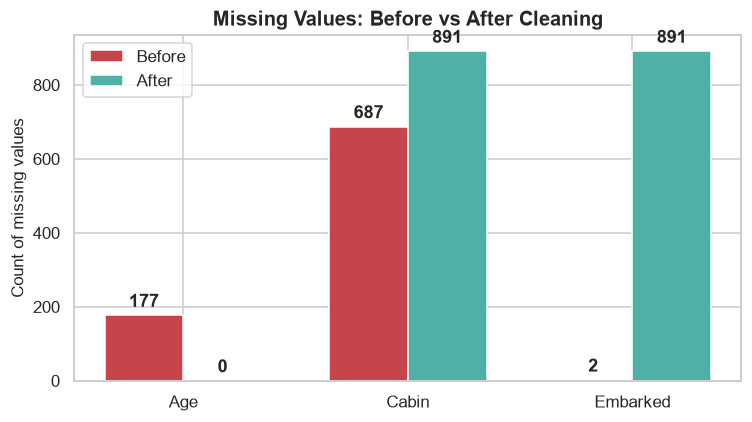

Total missing values remaining in df_clean: 0 (target: 0)


In [54]:
# Missing values: before vs after cleaning, in a single side-by-side chart
before_missing = df.isnull().sum()
before_missing = before_missing[before_missing > 0]

# reindex against df_clean's columns: a column that was DROPPED (like Cabin)
# counts as 0 missing here, since it no longer exists to have missing values
after_missing = df_clean.reindex(columns=before_missing.index).isnull().sum()

x = np.arange(len(before_missing))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, before_missing.values, width, color=PALETTE[3], label="Before")
bars2 = ax.bar(x + width/2, after_missing.values, width, color=PALETTE[2], label="After")

ax.set_xticks(x)
ax.set_xticklabels(before_missing.index)
ax.set_ylabel("Count of missing values")
ax.set_title("Missing Values: Before vs After Cleaning")
ax.legend()
ax.bar_label(bars1, padding=3, fontweight="bold")
ax.bar_label(bars2, padding=3, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Total missing values remaining in df_clean: {df_clean.isnull().sum().sum()} (target: 0)")


## 4. Encode Categorical Features

- **`Sex`** → **Label Encoding** (binary: male/female → 1/0). Fine here since
  there's no ordinal relationship to worry about with only 2 classes.
- **`Embarked`** → **One-Hot Encoding** (3 ports: C/Q/S). Label encoding would
  wrongly imply an order (e.g. Q > C), so we one-hot encode instead and drop
  one column to avoid redundancy (`drop_first=True`).

In [50]:
# Label Encoding: Sex (binary category)
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
df_clean["Sex"] = le.fit_transform(df_clean["Sex"])
sex_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Sex encoding map:", sex_mapping)

# One-Hot Encoding: Embarked (3 categories, no natural order)
df_clean = pd.get_dummies(df_clean, columns=["Embarked"], prefix="Embarked", drop_first=True)

print("\nColumns after encoding:")
print(df_clean.columns.tolist())
df_clean.head()


Sex encoding map: {'female': np.int64(0), 'male': np.int64(1)}

Columns after encoding:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


## 5. Detect & Remove Outliers

We use the **IQR (Interquartile Range) method**: anything below `Q1 - 1.5*IQR`
or above `Q3 + 1.5*IQR` is flagged as an outlier.

Applied only to **`Age`** and **`Fare`** — these are continuous variables where
extreme values genuinely distort statistics and model training. `SibSp` and
`Parch` are small integer *counts* (e.g. "3 siblings aboard"), so IQR-flagging
them would just discard legitimate large families rather than real anomalies.

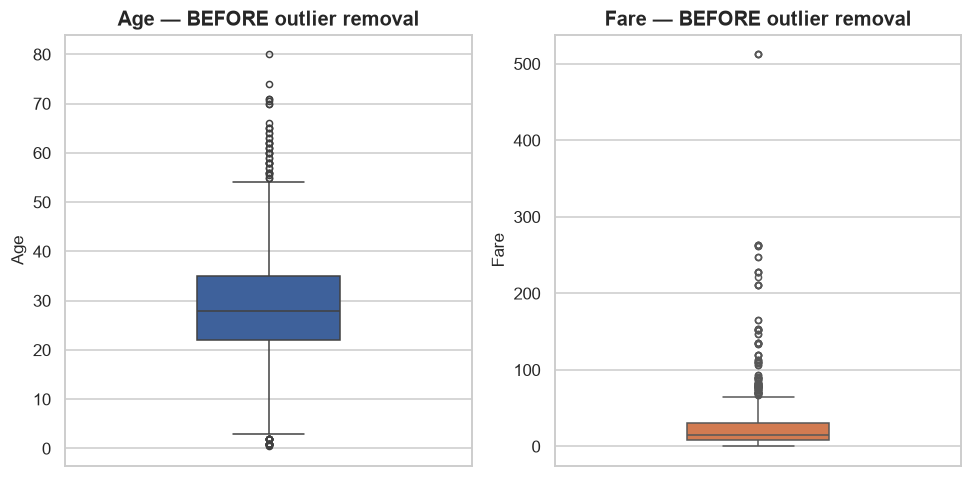

In [55]:
outlier_cols = ["Age", "Fare"]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(9, 4.5))
for ax, col, color in zip(axes, outlier_cols, [PALETTE[0], PALETTE[1]]):
    sns.boxplot(y=df_clean[col], ax=ax, color=color, width=0.35, fliersize=4)
    ax.set_title(f"{col} — BEFORE outlier removal")
plt.tight_layout()
plt.show()


In [56]:
def remove_outliers_iqr(data, cols):
    """Remove rows where any of `cols` falls outside 1.5*IQR of its quartiles."""
    data = data.copy()
    for col in cols:
        Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

rows_before = len(df_clean)
df_no_outliers = remove_outliers_iqr(df_clean, outlier_cols)
rows_after = len(df_no_outliers)

print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Removed:     {rows_before - rows_after} rows ({(rows_before-rows_after)/rows_before*100:.1f}%)")

Rows before: 891
Rows after:  718
Removed:     173 rows (19.4%)


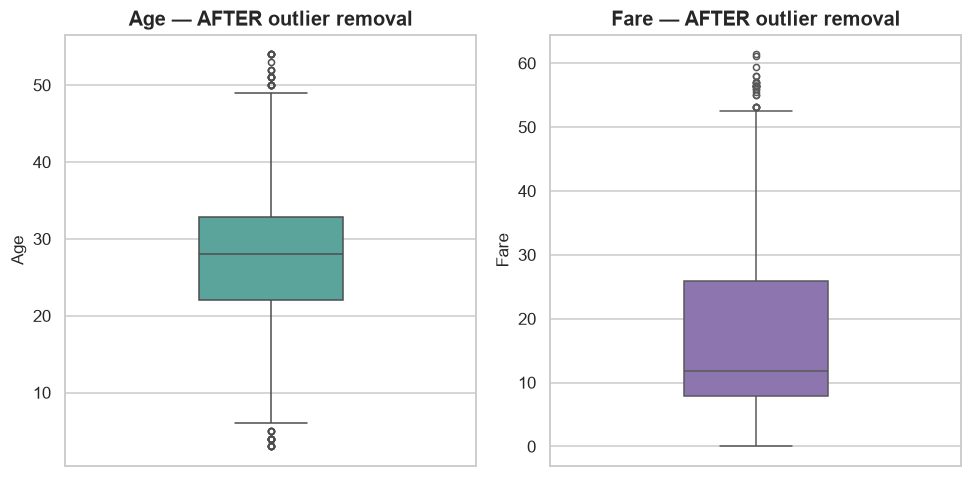

In [57]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(9, 4.5))
for ax, col, color in zip(axes, outlier_cols, [PALETTE[2], PALETTE[4]]):
    sns.boxplot(y=df_no_outliers[col], ax=ax, color=color, width=0.35, fliersize=4)
    ax.set_title(f"{col} — AFTER outlier removal")
plt.tight_layout()
plt.show()


## 6. Normalize / Standardize Numerical Features

We apply **StandardScaler** (z-score standardization: mean = 0, std = 1) to
the continuous numeric columns. This matters for distance-based or
gradient-based ML algorithms (KNN, SVM, logistic regression, neural nets)
which are sensitive to features being on very different scales
(`Fare` ranges 0–512, `Age` ranges 0–80).


In [58]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]

scaler = StandardScaler()
df_final = df_no_outliers.copy()
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

comparison = pd.DataFrame({
    "before_mean": df_no_outliers[num_cols].mean(),
    "before_std": df_no_outliers[num_cols].std(),
    "after_mean": df_final[num_cols].mean().round(3),
    "after_std": df_final[num_cols].std().round(3),
})
comparison

,before_mean,before_std,after_mean,after_std
Age,28.079387,10.012369,0.0,1.001
Fare,17.193204,13.244507,-0.0,1.001
SibSp,0.413649,0.855001,-0.0,1.001
Parch,0.317549,0.784792,0.0,1.001


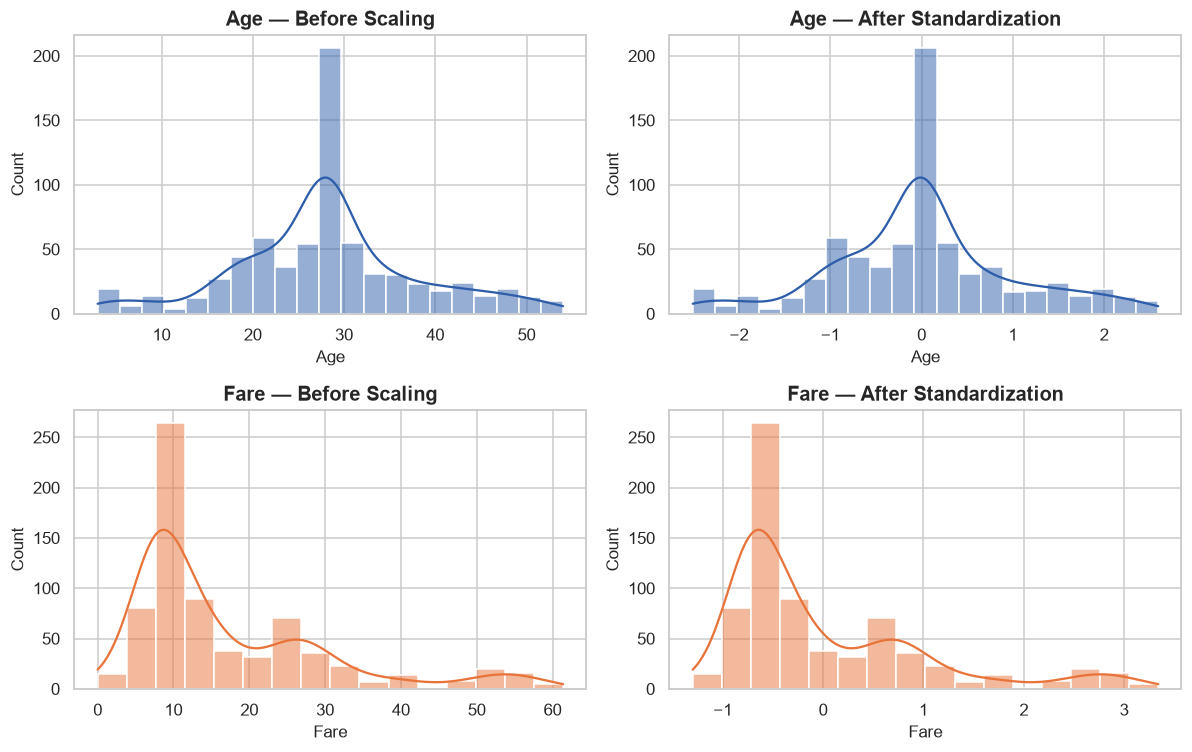

In [59]:
# Visual before/after of scaling for Age and Fare -- shape stays identical,
# only the x-axis scale changes (this is standardization, not a distribution change).
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(df_no_outliers["Age"], kde=True, ax=axes[0, 0], color=PALETTE[0])
axes[0, 0].set_title("Age — Before Scaling")

sns.histplot(df_final["Age"], kde=True, ax=axes[0, 1], color=PALETTE[0])
axes[0, 1].set_title("Age — After Standardization")

sns.histplot(df_no_outliers["Fare"], kde=True, ax=axes[1, 0], color=PALETTE[1])
axes[1, 0].set_title("Fare — Before Scaling")

sns.histplot(df_final["Fare"], kde=True, ax=axes[1, 1], color=PALETTE[1])
axes[1, 1].set_title("Fare — After Standardization")

plt.tight_layout()
plt.show()

## 7. Final Summary & Export

Recap of the full pipeline, then save the cleaned, encoded, scaled, and
outlier-free dataset — ready to feed into an ML model.

In [60]:
summary = pd.DataFrame({
    "Stage": [
        "Raw data",
        "After dropping Cabin/Name/Ticket/PassengerId",
        "After imputing Age & Embarked",
        "After encoding (Sex, Embarked)",
        "After removing outliers (Age, Fare)",
        "After standardizing numeric features",
    ],
    "Rows": [df.shape[0], df_clean.shape[0], df_clean.shape[0], df_clean.shape[0], df_no_outliers.shape[0], df_final.shape[0]],
    "Columns": [df.shape[1], df_clean.shape[1], df_clean.shape[1], df_clean.shape[1], df_no_outliers.shape[1], df_final.shape[1]],
})
summary

,Stage,Rows,Columns
0,Raw data,891,12
1,After dropping Cabin/Name/Ticket/PassengerId,891,9
2,After imputing Age & Embarked,891,9
3,"After encoding (Sex, Embarked)",891,9
4,"After removing outliers (Age, Fare)",718,9
5,After standardizing numeric features,718,9


In [61]:
df_final.to_csv("titanic_cleaned.csv", index=False)
print(f"Saved cleaned dataset -> titanic_cleaned.csv")
print(f"Final shape: {df_final.shape[0]} rows x {df_final.shape[1]} columns")
df_final.head()

Saved cleaned dataset -> titanic_cleaned.csv
Final shape: 718 rows x 9 columns


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.607611,0.686268,-0.40491,-0.751265,False,True
2,1,3,0,-0.207827,-0.484137,-0.40491,-0.700265,False,True
3,1,1,0,0.691688,0.686268,-0.40491,2.712961,False,True
4,0,3,1,0.691688,-0.484137,-0.40491,-0.690821,False,True
5,0,3,1,-0.007934,-0.484137,-0.40491,-0.659971,True,False


---
### Key takeaways
- Started with **891 rows, 12 columns**, several of them unusable identifiers or too sparse to trust (`Cabin`).
- Missing values were imputed with **median** (skewed numeric: `Age`) and **mode** (categorical: `Embarked`), not blindly dropped, to preserve sample size.
- Categorical features were encoded with the method that matched their nature — **label encoding** for binary, **one-hot** for unordered multi-class — to avoid injecting a false order.
- Outliers were removed using the **IQR rule**, applied only where it made statistical sense (continuous variables, not count variables).
- Numeric features were **standardized** so no single feature dominates a distance/gradient-based model purely because of its raw scale.
- Final dataset is fully numeric, has no missing values, and is ready for model training.
